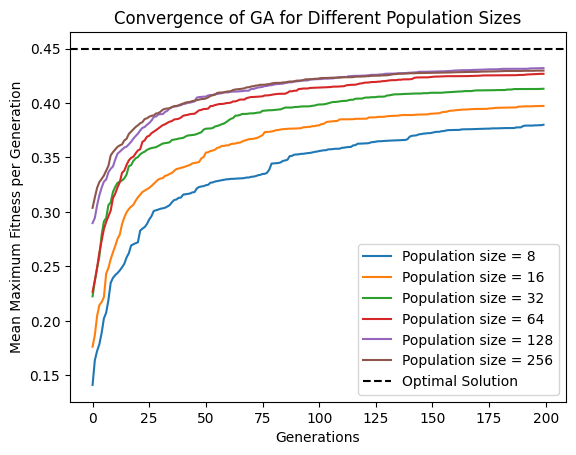

In [21]:
import pickle
import matplotlib.pyplot as plt
import pandas as pd

file_path1 = 'results_fit_ev_8.pickle'
with open(file_path1, 'rb') as file:
    # Deserialize and retrieve the variable from the file
    loaded_data8 = pickle.load(file)
gen_fit_mean8 = list(loaded_data8.mean())

file_path2 = 'results_fit_ev_16.pickle'
with open(file_path2, 'rb') as file:
    # Deserialize and retrieve the variable from the file
    loaded_data16 = pickle.load(file)
gen_fit_mean16 = list(loaded_data16.mean())

file_path3 = 'results_fit_ev_32.pickle'
with open(file_path3, 'rb') as file:
    # Deserialize and retrieve the variable from the file
    loaded_data32 = pickle.load(file)
gen_fit_mean32 = list(loaded_data32.mean())

file_path4 = 'results_fit_ev_64.pickle'
with open(file_path4, 'rb') as file:
    # Deserialize and retrieve the variable from the file
    loaded_data64 = pickle.load(file)
gen_fit_mean64 = list(loaded_data64.mean())

file_path5 = 'results_fit_ev_128.pickle'
with open(file_path5, 'rb') as file:
    # Deserialize and retrieve the variable from the file
   loaded_data128 = pickle.load(file)
gen_fit_mean128 = list(loaded_data128.mean())

file_path6 = 'results_fit_ev_256.pickle'
with open(file_path6, 'rb') as file:
    # Deserialize and retrieve the variable from the file
   loaded_data256 = pickle.load(file)
gen_fit_mean256 = list(loaded_data256.mean())

ax3=plt.figure()
plt.plot(gen_fit_mean8, label='Population size = 8')
plt.plot(gen_fit_mean16, label='Population size = 16')
plt.plot(gen_fit_mean32, label = 'Population size = 32')
plt.plot(gen_fit_mean64, label = 'Population size = 64')
plt.plot(gen_fit_mean128, label = 'Population size = 128')
plt.plot(gen_fit_mean256, label = 'Population size = 256')
plt.axhline(y=0.4497018281,linestyle = '--',color='black', label = 'Optimal Solution')
plt.legend(loc='lower right')
plt.ylabel('Mean Maximum Fitness per Generation')
plt.xlabel('Generations')
plt.title('Convergence of GA for Different Population Sizes')
plt.show()

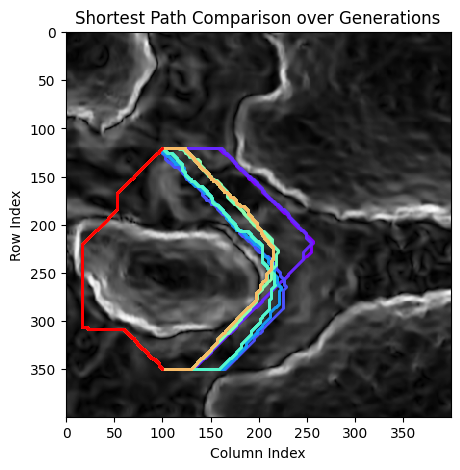

In [13]:
import rasterio as rio
from rasterio.plot import show
import matplotlib.cm as cm
import numpy as np


file_path7 = 'best_paths_64_200.pickle'
filename = "data/dems/lunargem_4to5_slope.tif"
# convert to a numpy array
dem = rio.open(filename)
slope_dem =dem.read(1)

with open(file_path7, 'rb') as file:
    # Deserialize and retrieve the variable from the file
    loaded_data_bp64 = pickle.load(file)
color = iter(cm.rainbow(np.linspace(0, 1, len(loaded_data_bp64))))
fig, ax = plt.subplots(1, figsize=(5, 5))
ax.imshow(slope_dem, origin='upper', cmap='Greys_r', interpolation='none')
for i in loaded_data_bp64:
            # Extract x, y coordinates for path plotting
    path_x = [point[1] for point in i]  # Col indices
    path_y = [point[0] for point in i]  # Row indices

        # Plot path
    c = next(color)
    plt.plot(path_x, path_y, marker='o', color=c, markersize=1, linewidth=0.5)

plt.title('Shortest Path Comparison over Generations')
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.grid(False)
plt.show()

In [ ]:
import numpy as np
#import richdem as rd
import rasterio as rio
from rasterio.plot import show
import matplotlib.pyplot as plt
from time import perf_counter
import pandas as pd
import elevation 
import random
import pickle
import copy
import datetime
import BORAS_v1
import BORAS
def evolutionary_algorithm(grid_size,start,end,moves, pop, pop_size, max_generations, deloop_flag,norm_fitness,max_slope,slope_dem):
    generations = 0
    fitnesses_gen = []
    gen_compt = []
    while not BORAS.termination_condition(generations,max_generations):
        t1_start = perf_counter() 
        generations += 1

        #BUILD NEXT GEN
        next_gen = []  

        #SELECT POPULATION FOR NEXT GEN
        selected_pop_size = int(pop_size/8)
        select_fitness = copy.deepcopy(norm_fitness)
        pop_w_elite = copy.deepcopy(pop)
        elite_pop = BORAS.select_pop_max(pop,select_fitness, pop_size, selected_pop_size*2)
        select_fitness = copy.deepcopy(norm_fitness)
        selected_pop = BORAS.select_pop_rand(pop_w_elite,select_fitness, pop_size, selected_pop_size*2)
        selected_pop = selected_pop +  elite_pop
        

        #ELITE
        for i in range(selected_pop_size*2):
            next_gen.append(elite_pop[i])

        pop_indexes = list(np.arange(0,(selected_pop_size*4),1,dtype=int))

        #GENERAL    
        for i in range(0, (selected_pop_size*4),2):
            i,j = random.sample(pop_indexes,k=2)
            pop_indexes.remove(i)
            pop_indexes.remove(j)
            parent1 =[]
            parent2=[]
            child1=[]
            child2=[]
            parent1 , parent2 = selected_pop[i],selected_pop[j]
            child1,child2 = BORAS.crossover(parent1,parent2, moves, grid_size), BORAS.crossover(parent2,parent1, moves, grid_size)
            #MUTATION
            child1,child2 = BORAS.mutation(child1,end, moves, grid_size),BORAS.mutation(child2,end, moves, grid_size)
            next_gen.append(child1)
            next_gen.append(child2)

        #IMIGRANT POPULATION
        for i in range(selected_pop_size*2):
            x=random.randint(1,3)
            imigrant = BORAS.create_path(start,end,moves, grid_size,num_points=x)
            next_gen.append(imigrant)
        if len(next_gen) != pop_size:
            print("Next GEN Size different than Pop Size")
            break  
        
        pop[:] = next_gen

        #EVALUATE POPULATION
        norm_fitness = []
        norm_fitness,tot_slope,tot_distance = BORAS.normalize_pop(pop,start,end,grid_size,pop_size,max_slope,slope_dem)
        if norm_fitness == [0]*len(norm_fitness):
            print('Norm_fitness is full of zeros')
            break 

        #DELOOP
        for i in range(pop_size):
            if deloop_flag == True:
                delooped_path = BORAS.deloop(pop[i],grid_size,moves)
                delooped_fitness = BORAS.normalize_path(delooped_path,start,end, grid_size, max_slope,slope_dem)
                if norm_fitness[i] <= delooped_fitness:
                    pop[i] = delooped_path
                    norm_fitness[i] = delooped_fitness

        #EVALUATE POPULATION
        norm_fitness = []
        norm_fitness,tot_slope,tot_distance = BORAS.normalize_pop(pop,start,end,grid_size,pop_size,max_slope,slope_dem)
        for i in range(pop_size):
            if norm_fitness == [0]*len(norm_fitness):
                print('Norm_fitness is full of zeros')
                break 

        #GENERATION INFO
        best_fitness = max(norm_fitness)
        fitnesses_gen.append(best_fitness)
        best_path_idx = norm_fitness.index(best_fitness)
        print(f'Generation {generations}: Best fitness = {best_fitness}.')
        t1_stop = perf_counter()
        gen_compt.append(t1_stop-t1_start)
    best_path = pop[best_path_idx]
    best_t_dist = tot_distance[best_path_idx]
    best_t_slp =  tot_slope[best_path_idx]
    print('Total distance:',best_t_dist)
    print('Total slope:',best_t_slp)
    
    

    return best_path, fitnesses_gen, gen_compt


save_path = 'results_compt_ev_32.pickle'
def ga():
    t1_start = perf_counter() 

    #DEM 
    
    filename = "data/dems/lunargem_4to5_slope.tif"
    dem = rio.open(filename)
    print(filename)
    slope_dem =dem.read(1)

    # SET GRID SIZE
    grid_size=(dem.shape[0],dem.shape[1])
    start=(120,100) #SELECT STARTING POINT
    end=(350,100) #SELECT ENDING POINT
    #moves=['U', 'D', 'L', 'R' ] #POSSIBLE MOVEMENTS: UP, DOWN, LEFT & RIGHT
    moves=["U", "D", "L", "R","UL", "DL", "UR","UL"]

    #SYSTEM CONSTRAINTS
    max_slope = 15

    # INITIALIZE POPULATION(DIFFERENT RANDOM PATHS)
    pop_size= 32 #Always multiples of 8!
    print("Population size =", pop_size)
    pop = []
    max_generations= 25
    deloop_flag = True


    for i in range(pop_size):
        x=random.randint(1,4)
        populant = BORAS_v1.create_path(start,end,moves, grid_size, num_points=x)
        pop.append(populant)

    #EVALUATE POPULATION
    norm_fitness = []
    norm_fitness,x,y = BORAS_v1.normalize_pop(pop,start,end,grid_size,pop_size,max_slope,slope_dem)
    for i in range(pop_size):
        if deloop_flag == True:
            delooped_path = BORAS_v1.deloop(pop[i],grid_size,moves)
            delooped_fitness = BORAS_v1.normalize_path(delooped_path,start,end, grid_size, max_slope,slope_dem)
            if norm_fitness[i] <= delooped_fitness:
                pop[i] = delooped_path
                norm_fitness[i] = delooped_fitness

    #GENERATION INFO
    best_fitness = max(norm_fitness)
    print(f'Generation 0: Best fitness = {best_fitness}.')
    
    # RUN EVOLUTIONARY ALGORITHM

    best_path, fitnesses_gen, gen_compt = evolutionary_algorithm(grid_size,start,end,moves, pop, pop_size, max_generations, deloop_flag,norm_fitness,max_slope,slope_dem)
    t1_stop = perf_counter()

    print('Best path found:',best_path)
    print("Elapsed time during the whole program in minutes:", (t1_stop-t1_start)/60)
    #traverse_time = calc_traverse_time(best_path)
    time_total = BORAS_v1.calc_traverse_time(best_path,slope_dem)
    traverse_time = str(datetime.timedelta(seconds=time_total))
    print ('Total traverse time:',traverse_time)

    return best_fitness,fitnesses_gen, gen_compt

fitnesses = []
gen_fit = []
gen_compts = []
runs = 25
for _ in range (runs):
    fitness, gen_fitness, gen_compt = ga()
    fitnesses.append(fitness)
    gen_compts.append(gen_compt)
    gen_fit.append(gen_fitness)
with open(save_path, 'wb') as file:
    pickle.dump(gen_compts,file)

In [ ]:
file_path10 = 'results_compt_ev_8.pickle'
with open(file_path10, 'rb') as file:
    # Deserialize and retrieve the variable from the file
    loaded_data10 = pd.DataFrame(pickle.load(file))
loaded_data10 = list(loaded_data10.mean())
compt8 = np.mean(np.array(loaded_data10))

file_path11 = 'results_compt_ev_16.pickle'
with open(file_path11, 'rb') as file:
    # Deserialize and retrieve the variable from the file
    loaded_data11 = pd.DataFrame(pickle.load(file))
loaded_data11 = list(loaded_data11.mean())
compt16 = np.mean(np.array(loaded_data11))

file_path12 = 'results_compt_ev_32.pickle'
with open(file_path12, 'rb') as file:
    # Deserialize and retrieve the variable from the file
    loaded_data12 = pd.DataFrame(pickle.load(file))
loaded_data12 = list(loaded_data12.mean())
compt32 = np.mean(np.array(loaded_data12))

compt = [compt8, compt16, compt32, compt32*2, compt32*4, compt32*8]
population_sizes = [8, 16, 32, 64, 128, 256]
ax4=plt.figure()
plt.plot(population_sizes,compt,linestyle = '-', marker = 'o', label='GA Algorithm')
#plt.plot(gen_fit_mean16, label='Population size = 16')
#plt.plot(gen_fit_mean32, label = 'Population size = 32')
#plt.plot(gen_fit_mean64, label = 'Population size = 64')
plt.legend(loc='lower right')
plt.ylabel('Computation Time per Generation in Seconds ')
plt.xlabel('Population Size')
plt.title('Evolution of Computation Time per Generation vs. Population')
plt.show()

51
31


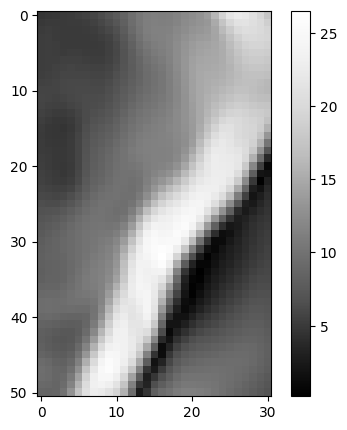

In [15]:
min_y = 25
min_x = 59
max_y = 76
max_x = 90

# load the geotiff (a DSM in this case) and read the data - only one index in this case

dsm_data = dem.read()[0]

# crop the data
dsm_crop = dsm_data[min_y:max_y, min_x:max_x]

# make a copy of the geotiff metadata
new_meta = dem.meta.copy()

# create a translation transform to shift the pixel coordinates
crop = rio.Affine.translation(min_x, min_y)

# prepend the pixel translation to the original geotiff transform
new_xform = dem.transform * crop

# update the geotiff metadata with the new dimensions and transform
new_meta['width'] = max_x - min_x
new_meta['height'] = max_y - min_y
new_meta['transform'] = new_xform

# write the cropped geotiff to disk
with rio.open('crop-file', "w", **new_meta) as dest:
    dest.write(dsm_crop.reshape(1,dsm_crop.shape[0], dsm_crop.shape[1]))


filename_c = "crop-file"


# convert to a numpy array
dem_c = rio.open(filename_c)
print(dem_c.shape[0])
print(dem_c.shape[1])

dem_array = dem_c.read(1).astype('float64')


fig2, ax = plt.subplots(1, figsize=(5, 5))
plt.imshow(dem_array, cmap='Greys_r',interpolation='none')
plt.colorbar()
plt.axis("on")
plt.show()
dem_c.close()

In [14]:
import numpy as np
def find_closest(k):
    lst = [8,16,32,64,128,256,512,1024]
    closest_num = lst[0]
    for num in lst:
        if abs(num - k) < abs(closest_num - k):
            closest_num = num
        if num > k:
            break
    return closest_num


grid_size =(430,600)
print(grid_size[0])
t=np.sqrt((grid_size[0]**2)+(grid_size[1]**2))/5
print(t)
p = find_closest(t)
print(p)


430
147.63468427168462
128


In [ ]:
def evolutionary_algorithm2(grid_size,start,end,moves, pop, pop_size, max_generations, deloop_flag,norm_fitness_old,max_slope,slope_dem):
    generations = 0
    fitnesses_gen = []
    best_fitness_r = 0
    same = 0
    flag =1
    while (same<= 150 or flag ==1.5) and not termination_condition(generations,max_generations):
        
        t1_start = perf_counter() 
        generations += 1
        old_best_fitness = best_fitness_r
        #BUILD NEXT GEN
        next_gen = []  
        #SELECT POPULATION FOR NEXT GEN
        selected_pop_size = int(pop_size/8)
        select_fitness = copy.deepcopy(norm_fitness_old)
        pop_copy = copy.deepcopy(pop)
        selected_pop = select_pop_rand(pop_copy,select_fitness, pop_size, selected_pop_size*7)
        
        pop_indexes = list(np.arange(0,(selected_pop_size*7),1,dtype=int))

        #GENERAL    
        for i in range(0, (selected_pop_size*7),2):
            j = i +1
            pop_indexes.remove(i)
            pop_indexes.remove(j)
            parent1 =[]
            parent2=[]
            child1=[]
            child2=[]
            parent1 , parent2 = selected_pop[i],selected_pop[j]
            child1,child2 = crossover(parent1,parent2, moves, grid_size,slope_dem), crossover(parent2,parent1, moves, grid_size,slope_dem)
            #MUTATION
            child1,child2 = mutation(child1,end, moves, grid_size,slope_dem),mutation(child2,end, moves, grid_size,slope_dem)
            next_gen.append(child1)
            next_gen.append(child2)

        #IMIGRANT POPULATION
        for i in range(selected_pop_size*1):
            x=random.randint(1,20) # Size according length of path or grid
            imigrant = create_path(start,end,moves, grid_size,slope_dem,num_points=x)
            next_gen.append(imigrant)
        if len(next_gen) != pop_size:
            print("Next GEN Size different than Pop Size")
            break 
    

        #EVALUATE POPULATION
        norm_fitness = []
        norm_fitness,tot_slope,tot_distance = normalize_pop(next_gen,start,end,grid_size,pop_size,max_slope,slope_dem)
        if norm_fitness == [0]*len(norm_fitness):
            print('Norm_fitness is full of zeros')
            break 

        #DELOOP
        for i in range(pop_size):
            if deloop_flag == True:
                delooped_path = deloop(next_gen[i],grid_size,moves)
                delooped_fitness = normalize_path(delooped_path,start,end, grid_size, max_slope,slope_dem)
                if norm_fitness[i] <= delooped_fitness:
                    next_gen[i] = delooped_path
                    norm_fitness[i] = delooped_fitness

        #EVALUATE POPULATION
        norm_fitness = []
        norm_fitness,tot_slope,tot_distance = normalize_pop(next_gen,start,end,grid_size,pop_size,max_slope,slope_dem)
        for i in range(pop_size):
            if norm_fitness == [0]*len(norm_fitness):
                print('Norm_fitness is full of zeros')
                break 
        
        for i in range(pop_size):
            if norm_fitness[i]>= norm_fitness_old[i] and next_gen[i] not in pop:
                pop[i] = next_gen[i]
            else:
                norm_fitness[i] = norm_fitness_old[i]
            
        norm_fitness_old = norm_fitness
        #GENERATION INFO
        best_fitness = max(norm_fitness)
        best_fitness_r = round(best_fitness,12)

        fitnesses_gen.append(best_fitness)
        best_path_idx = norm_fitness.index(best_fitness)
        print(f'Generation {generations}: Best fitness = {best_fitness}.')
        t1_stop = perf_counter()
        if best_fitness_r == old_best_fitness:
            same = same + 1
        else:
            same = 0
        best_path = pop[best_path_idx]
        _,flag = calc_slope(best_path,max_slope,slope_dem)
    best_t_dist = tot_distance[best_path_idx]
    best_t_slp =  _
    print('Total distance:',best_t_dist)
    print('Total slope:',best_t_slp)
    
    gen_compt = (t1_stop-t1_start)

    return best_path, fitnesses_gen, gen_compt

def ga(start,end,dem):
    t1_start = perf_counter() 

    #DEM 

    #filename = "data/dems/lunargem_4to5_slope.tif"
    #dem = rio.open(filename)
    #print(filename)
    slope_dem = dem.read(1).astype('float64')

    # SET GRID SIZE
    grid_size=(dem.shape[0],dem.shape[1])
    moves=["U", "D", "L", "R","UL", "DL", "UR", "DR"]

    #SYSTEM CONSTRAINTS
    max_slope = 15

    # INITIALIZE POPULATION(DIFFERENT RANDOM PATHS)
    #pop_size= 128 #Always multiples of 8!
    pop_size = find_closest((np.sqrt(grid_size[0]**2+grid_size[1]**2)/5))
    print("Population size =", pop_size)
    pop = []
    max_generations= 1000
    deloop_flag = True


    for i in range(pop_size):
        x=random.randint(0,2) #Size depending on the length of the path or grid size
        populant = create_path(start,end,moves, grid_size, slope_dem, num_points=x)
        pop.append(populant)

    #EVALUATE POPULATION
    norm_fitness_old = []
    norm_fitness_old,tot_slope,tot_distance = normalize_pop(pop,start,end,grid_size,pop_size,max_slope,slope_dem)
    for i in range(pop_size):
        if deloop_flag == True:
            delooped_path = deloop(pop[i],grid_size,moves)
            delooped_fitness = normalize_path(delooped_path,start,end, grid_size, max_slope,slope_dem)
            if norm_fitness_old[i] <= delooped_fitness:
                pop[i] = delooped_path
                norm_fitness_old[i] = delooped_fitness

    #GENERATION INFO
    best_fitness = max(norm_fitness_old)
    best_path_idx = norm_fitness_old.index(best_fitness)
    print(f'Generation 0: Best fitness = {best_fitness}.')
    
    # RUN EVOLUTIONARY ALGORITHM

    best_path,fitnesses_gen,gen_compt = evolutionary_algorithm2(grid_size,start,end,moves, pop, pop_size, max_generations, deloop_flag,norm_fitness_old,max_slope,slope_dem)
    t1_stop = perf_counter()

    print('Best path found:',best_path)
    print("Elapsed time during the whole program in minutes:", (t1_stop-t1_start)/60)
    #traverse_time = calc_traverse_time(best_path)
    time_total = calc_traverse_time(best_path,slope_dem)
    traverse_time = str(datetime.timedelta(seconds=time_total))
    print ('Total traverse time:',traverse_time)
    return best_fitness,fitnesses_gen,time_total,best_path
